
### EX: CNN Fine-Tuning & Edge Evaluation

In this exercise, we will simulate fine-tuning a pre-trained CNN to classify satellite terrain data (e.g., EuroSAT classes: Desert vs. Runway). We will plot the learning curves to verify training health, generate a confusion matrix to evaluate our mission risks, and calculate our operational inference speed.

* **Simulate Satellite Spatial Data:** Generate synthetic image arrays representing top-down terrain features.

* **Configure Fine-Tuning:** Load a base model, freeze the early layers, and unfreeze the top layers for domain specialization.

* **Train & Visualize:** Train the model, capturing validation metrics, and plot the accuracy and loss curves over time.

* **Extract Performance Logs:** Compute the precision, recall, and exact inference speed in milliseconds.

In [ ]:
# Only run this cell after downloading and selecting your kernel
!python.exe -m pip install --upgrade pip
!pip install numpy matplotlib scikit-learn pandas tensorflow

Executing Fine-Tuning Protocol on Satellite Features...
Fine-Tuning Complete.



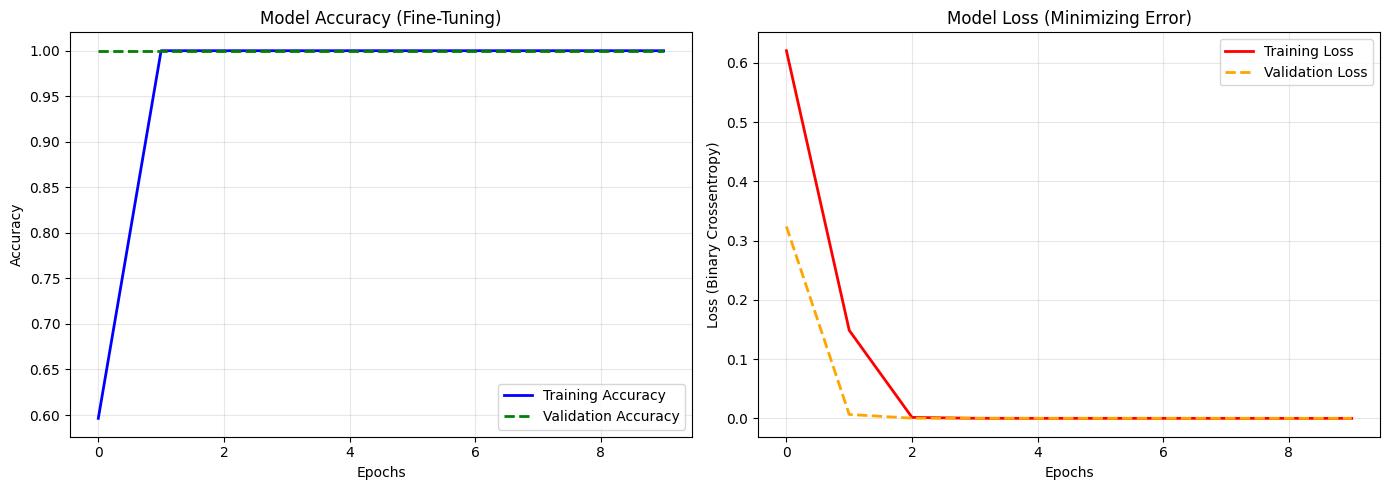

Benchmarking Edge Inference Latency...
Total Latency for 120 frames: 112.52 ms
Inference Velocity: 1066.47 Frames Per Second (FPS)

=== COMMANDER'S RISK LEDGER (CONFUSION MATRIX) ===
True Deserts Correctly Ignored: 60
False Alarms (Civilian/Desert Flagged as Threat) [False Positives]: 0
Missed Threats (Runway Left Unprocessed) [False Negatives]: 0
True Threats Correctly Identified: 60

=== DETAILED TACTICAL METRICS ===
              precision    recall  f1-score   support

      Desert       1.00      1.00      1.00        60
      Runway       1.00      1.00      1.00        60

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



In [ ]:

import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

# 1. Generate Synthetic Top-Down Satellite Patches (64x64 pixels, 3 color channels)
np.random.seed(42)
n_samples = 600
img_size = 64

X = np.random.normal(0, 1, (n_samples, img_size, img_size, 3))
y = np.zeros(n_samples)

# Inject synthetic spatial structures (simulating top-down visual signatures)
for i in range(n_samples):
    if i % 2 == 0:
        # Class 0: Flat Desert Terrain (homogeneous noise)
        X[i] += 0.2
        y[i] = 0
    else:
        # Class 1: Hidden Runway Concrete (sharp high-contrast line across the center)
        X[i, 30:34, :, :] += 2.0  
        y[i] = 1

X_train, X_test = X[:480], X[480:]
y_train, y_test = y[:480], y[480:]

# 2. Construct a Base CNN Architecture (Simulating a Pre-Trained Model)
base_model = Sequential([
    Input(shape=(img_size, img_size, 3)),
    Conv2D(16, (3, 3), activation='relu', name='early_layer_edges'),
    MaxPooling2D((2, 2)),
    Conv2D(32, (3, 3), activation='relu', name='mid_layer_shapes'),
    MaxPooling2D((2, 2)),
])

# 3. Apply the Fine-Tuning Protocol
# Freeze the early layer (retaining foundational edge detection capabilities)
base_model.get_layer('early_layer_edges').trainable = False

# Unfreeze the upper layer to allow adaptation to top-down runway geometry
base_model.get_layer('mid_layer_shapes').trainable = True

# Append our custom tactical classification head
fine_tuned_model = Sequential([
    base_model,
    Flatten(),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid') # Binary output: Desert (0) vs Runway (1)
])

fine_tuned_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 4. Train the Head and Unfrozen Upper Layer
print("Executing Fine-Tuning Protocol on Satellite Features...")
# Capture the history object and add a 20% validation split to track generalization
history = fine_tuned_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
print("Fine-Tuning Complete.\n")

# 5. Visualize the Learning Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Accuracy Curve
axes[0].plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='green', linewidth=2, linestyle='--')
axes[0].set_title('Model Accuracy (Fine-Tuning)')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot B: Loss Curve
axes[1].plot(history.history['loss'], label='Training Loss', color='red', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2, linestyle='--')
axes[1].set_title('Model Loss (Minimizing Error)')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss (Binary Crossentropy)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 6. Measure Edge Performance & Latency
print("Benchmarking Edge Inference Latency...")
start_time = time.time()
predictions = fine_tuned_model.predict(X_test, verbose=0)
end_time = time.time()

total_latency = (end_time - start_time) * 1000  # Convert to milliseconds
per_frame_latency = total_latency / len(X_test)
fps = 1000 / per_frame_latency

print(f"Total Latency for {len(X_test)} frames: {total_latency:.2f} ms")
print(f"Inference Velocity: {fps:.2f} Frames Per Second (FPS)\n")

# Convert probabilities to binary tactical decisions
y_pred = (predictions > 0.5).astype(int).flatten()

# 7. Generate the Operational Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("=== COMMANDER'S RISK LEDGER (CONFUSION MATRIX) ===")
print(f"True Deserts Correctly Ignored: {cm[0][0]}")
print(f"False Alarms (Civilian/Desert Flagged as Threat) [False Positives]: {cm[0][1]}")
print(f"Missed Threats (Runway Left Unprocessed) [False Negatives]: {cm[1][0]}")
print(f"True Threats Correctly Identified: {cm[1][1]}\n")

print("=== DETAILED TACTICAL METRICS ===")
print(classification_report(y_test, y_pred, target_names=['Desert', 'Runway']))


### Interpreting the Results

First, evaluate the **Learning Curves** generated by the script:

* **The Accuracy and Loss Pair:** The blue/red solid lines represent how well the model is learning the training data. The green/orange dashed lines represent the *Validation* data—the simulated combat environment the model has never seen.
* **Diagnosing Health:** Ideally, both the Training and Validation lines should move together closely. If Training Loss drops to zero, but Validation Loss spikes upwards midway through, the model has catastrophically overfitted. If the Validation curve remains stable, your fine-tuning protocol successfully adapted the network without destroying its foundational logic.

Next, take note of your **Inference Velocity (FPS)**. In an operational environment, if your autonomous drone flies at high speeds, this number determines your spatial resolution footprint—how often your sensor can scan the ground for threats.

Finally, look at the **Confusion Matrix**. Notice the explicit count of False Alarms vs. Missed Threats. If this model were plugged into an automated weapon system, the False Positives count ($cm[0][1]$) represents your risk of unprovoked collateral damage, while your False Negatives count ($cm[1][0]$) represents the gaps in your defensive coverage where an adversary could slip past your screen undetected.